# SCPMNet First Batch GT Alignment Check

This notebook builds the same `SCPMDataModule` used by training, loads the first batch, and overlays crop-local ground-truth spheres on the CT slices. Use it to verify that labels line up with visible nodules before trusting FROC results.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Circle

# Make imports work when the notebook is launched from src/det/SCPMNet or repo root.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src" / "det" / "SCPMNet").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.det.SCPMNet.datamodule import SCPMDataModule

## Configuration

These defaults mirror the paper-style config. Change `CSV_PATH`, `DATA_ROOT`, `BATCH_SIZE`, or `SPLIT` if needed.

In [2]:
CSV_PATH = "/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/data/lidc_process/lidc_labels_clean_flagged_smaller.csv"
DATA_ROOT = "/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/data/lidc_process"

SPLIT = "train"  # train, val, or test_crop. Use train/val for GT crop checks.
BATCH_SIZE = 2
NUM_WORKERS = 0
CROP_SIZE = (96, 96, 96)
SAMPLES_PER_VOLUME = 4
POSITIVE_CROP_PROB = 1.0  # 1.0 forces nodule-centered crops for easier visual checks.
CLIP = (-1000.0, 400.0)

torch.manual_seed(233)
np.random.seed(233)

In [24]:
dm = SCPMDataModule(
    csv_path=CSV_PATH,
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    crop_size=CROP_SIZE,
    samples_per_volume=SAMPLES_PER_VOLUME,
    clip=CLIP,
    positive_crop_prob=POSITIVE_CROP_PROB,
    mask_path_column=None,
    skip_missing_images=True,
    test_full_volume=False,
    sliding_window_stride=(24, 24, 24),
)

if SPLIT in ("train", "val"):
    dm.setup("fit")
    loader = dm.train_dataloader() if SPLIT == "train" else dm.val_dataloader()
else:
    dm.setup("test")
    loader = dm.test_dataloader()

it = iter(loader)

first_batch = next(it)
second_batch = next(it)
third_batch = next(it)
fourth_batch = next(it)
images = first_batch["image"].cpu().numpy()[:, 0]  # [B, Z, Y, X]
annots = first_batch["annot"].cpu().numpy()       # [B, N, 4] as z, y, x, radius in crop coordinates
seriesuids = first_batch["seriesuid"]

print("Batch image shape:", images.shape)
print("Batch annot shape:", annots.shape)
print("Seriesuids:", seriesuids)
for i, sid in enumerate(seriesuids):
    valid = annots[i, :, 3] > 0
    print(i, sid, "valid GT:", int(valid.sum()), annots[i, valid])

Loading seriesuid=LIDC-IDRI-0003 for sample index 10 with 3 annotation rows.
Loading seriesuid=LIDC-IDRI-0005 for sample index 12 with 3 annotation rows.
Loading seriesuid=LIDC-IDRI-0187 for sample index 19 with 4 annotation rows.
Loading seriesuid=LIDC-IDRI-0001 for sample index 3 with 1 annotation rows.
Loading seriesuid=LIDC-IDRI-0002 for sample index 5 with 1 annotation rows.
Loading seriesuid=LIDC-IDRI-0005 for sample index 15 with 3 annotation rows.
Loading seriesuid=LIDC-IDRI-0003 for sample index 11 with 3 annotation rows.
Loading seriesuid=LIDC-IDRI-0002 for sample index 6 with 1 annotation rows.
Batch image shape: (2, 96, 96, 96)
Batch annot shape: (2, 2, 4)
Seriesuids: ['LIDC-IDRI-0003', 'LIDC-IDRI-0005']
0 LIDC-IDRI-0003 valid GT: 1 [[62.  54.  61.5  6.5]]
1 LIDC-IDRI-0005 valid GT: 2 [[49.  69.5  4.5  3. ]
 [68.  49.5 67.5  3. ]]


## Helpers

In [25]:
def denormalize_for_display(image):
    # Dataset normalizes CT from HU clip range into [-1, 1]. This maps back to [0, 1] for display.
    return np.clip((image + 1.0) / 2.0, 0.0, 1.0)


def valid_annots(sample_annots):
    return sample_annots[sample_annots[:, 3] > 0]


def annots_visible_on_slice(sample_annots, z, tolerance=0.75):
    gt = valid_annots(sample_annots)
    if len(gt) == 0:
        return gt
    return gt[np.abs(gt[:, 0] - z) <= np.maximum(gt[:, 3], tolerance)]


def plot_sample_slice(sample_idx=0, z=None, tolerance=0.75, figsize=(7, 7)):
    image = images[sample_idx]
    sample_annots = annots[sample_idx]
    gt = sample_annots
    print(f"Sample {sample_idx}  seriesuid={seriesuids[sample_idx]}  GT nodules (z, y, x, radius): {gt}")
    if z is None:
        z = int(round(gt[0, 0])) if len(gt) else image.shape[0] // 2
    z = int(np.clip(z, 0, image.shape[0] - 1))
    #visible = annots_visible_on_slice(sample_annots, z, tolerance=tolerance)
    visible = sample_annots  # Show all GT for easier visual checks, even if some may be slightly off-slice.

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(denormalize_for_display(image[z]), cmap="gray", vmin=0, vmax=1)
    for n, (cz, cy, cx, radius) in enumerate(visible, start=1):
        dz = abs(float(cz) - z)
        slice_radius = max(float(radius) ** 2 - dz ** 2, 0.0) ** 0.5
        ax.add_patch(Circle((float(cx), float(cy)), max(slice_radius, 1.5), fill=False, color="lime", linewidth=2.0))
        ax.scatter([float(cx)], [float(cy)], marker="+", c="yellow", s=80, linewidths=2.0)
        ax.text(float(cx) + 2, float(cy) + 2, str(n), color="yellow", fontsize=10)

    ax.set_title(f"sample={sample_idx}  series={seriesuids[sample_idx]}  z={z}  visible GT={len(visible)}")
    ax.set_xlim(0, image.shape[2] - 1)
    ax.set_ylim(image.shape[1] - 1, 0)
    ax.set_axis_off()
    plt.show()

## Static Check

This plots one slice near the first GT center for every sample in the batch.

Sample 0  seriesuid=LIDC-IDRI-0003  GT nodules (z, y, x, radius): [[62.  54.  61.5  6.5]
 [ 0.   0.   0.   0. ]]


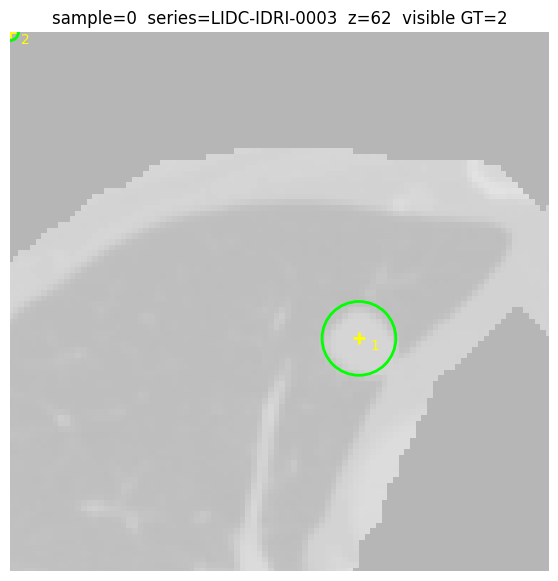

Sample 1  seriesuid=LIDC-IDRI-0005  GT nodules (z, y, x, radius): [[49.  69.5  4.5  3. ]
 [68.  49.5 67.5  3. ]]


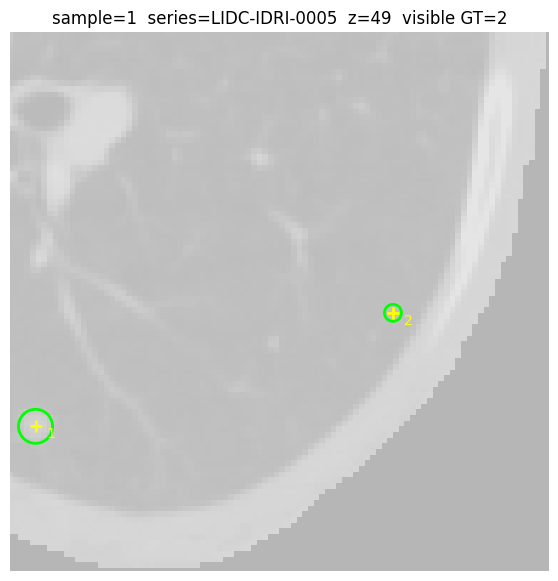

In [26]:
for sample_idx in range(len(seriesuids)):
    gt = annots[sample_idx]
    z = int(round(gt[0, 0])) if len(gt) else images.shape[1] // 2
    plot_sample_slice(sample_idx=sample_idx, z=z)

## Interactive Slice Viewer

Move through `z` slices and switch batch samples. Green circles are GT sphere cross-sections; yellow crosses are GT centers.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    sample_widget = widgets.IntSlider(value=0, min=0, max=len(seriesuids) - 1, step=1, description="sample")
    z_widget = widgets.IntSlider(value=images.shape[1] // 2, min=0, max=images.shape[1] - 1, step=1, description="z")
    tolerance_widget = widgets.FloatSlider(value=0.75, min=0.0, max=5.0, step=0.25, description="tol")

    def update_z_range(*_):
        sample_idx = sample_widget.value
        gt = annots[sample_idx]
        z_widget.max = images[sample_idx].shape[0] - 1
        z_widget.value = int(round(gt[0, 0])) if len(gt) else images[sample_idx].shape[0] // 2

    sample_widget.observe(update_z_range, names="value")
    update_z_range()

    ui = widgets.HBox([sample_widget, z_widget, tolerance_widget])
    out = widgets.interactive_output(
        plot_sample_slice,
        {"sample_idx": sample_widget, "z": z_widget, "tolerance": tolerance_widget},
    )
    display(ui, out)
except ImportError:
    print("ipywidgets is not installed. Use plot_sample_slice(sample_idx=0, z=48) manually.")

Output()

## Manual Calls

If widgets are unavailable, use calls like this:

In [7]:
# Example manual check:
# plot_sample_slice(sample_idx=0, z=48)
# plot_sample_slice(sample_idx=1, z=60)